In [1]:
using Plots
using StatsPlots
using FileIO
using EM
filepath = ".."
include("$(filepath)/code/qlearner.jl")
include("$(filepath)/code/hmm.jl")
include("$(filepath)/code/util.jl")
include("$(filepath)/code/em_scripts.jl")

subject_cov (generic function with 1 method)

In [2]:
fns_q = [
    ("q_leaf", run_q_leaf),
    ("q_leaf_γ2", run_q_leaf_γ2),
    ("q_leaf_retainbelief", run_q_leaf_retainbelief),
    ("q_leaf_stay", run_q_leaf_stay),
    ("q_leaf_stay_γ2", run_q_leaf_stay_γ2),
    ("q_leaf_stay_retainbelief", run_q_leaf_stay_retainbelief),
    ]

fns_q_stay = [
    ("q_leaf_stay_turn", run_q_leaf_stay_turn),
    ("q_leaf_stay_spatial", run_q_leaf_stay_spatial),
    ("q_leaf_stay_leafturn", run_q_leaf_stay_leafturn),
    ("q_leaf_stay_leafspatial", run_q_leaf_stay_leafspatial),
    ("q_leaf_stay_turn_leafspatial", run_q_leaf_stay_turn_leafspatial),
    ("q_leaf_stay_turn_leafturn", run_q_leaf_stay_turn_leafturn),
    ("q_leaf_stay_spatial_leafspatial", run_q_leaf_stay_spatial_leafspatial),
    ("q_leaf_stay_spatial_leafturn", run_q_leaf_stay_spatial_leafturn),
]

fns_q_stay_γ2 = [
    ("q_leaf_stay_turn_γ2", run_q_leaf_stay_turn_γ2),
    ("q_leaf_stay_spatial_γ2", run_q_leaf_stay_spatial_γ2),
    ("q_leaf_stay_leafturn_γ2", run_q_leaf_stay_leafturn_γ2),
    ("q_leaf_stay_leafspatial_γ2", run_q_leaf_stay_leafspatial_γ2),
    ("q_leaf_stay_turn_leafspatial_γ2", run_q_leaf_stay_turn_leafspatial_γ2),
    ("q_leaf_stay_turn_leafturn_γ2", run_q_leaf_stay_turn_leafturn_γ2),
    ("q_leaf_stay_spatial_leafspatial_γ2", run_q_leaf_stay_spatial_leafspatial_γ2),
    ("q_leaf_stay_spatial_leafturn_γ2", run_q_leaf_stay_spatial_leafturn_γ2),
]

fns_q_initialQ = [
    ("q_leaf_initialQ", run_q_leaf_initialQ),
    ("q_leaf_initialQ_γ2", run_q_leaf_initialQ_γ2),
    ("q_leaf_initialQ_retainbelief", run_q_leaf_initialQ_retainbelief),
    ("q_leaf_initialQ_stay", run_q_leaf_initialQ_stay),
    ("q_leaf_initialQ_stay_γ2", run_q_leaf_initialQ_stay_γ2),
    ("q_leaf_initialQ_stay_retainbelief", run_q_leaf_initialQ_stay_retainbelief),
]

fns_q_initialQ_stay = [
    ("q_leaf_initialQ_stay_turn", run_q_leaf_initialQ_stay_turn),
    ("q_leaf_initialQ_stay_spatial", run_q_leaf_initialQ_stay_spatial),
    ("q_leaf_initialQ_stay_leafturn", run_q_leaf_initialQ_stay_leafturn),
    ("q_leaf_initialQ_stay_leafspatial", run_q_leaf_initialQ_stay_leafspatial),
    ("q_leaf_initialQ_stay_turn_leafspatial", run_q_leaf_initialQ_stay_turn_leafspatial),
    ("q_leaf_initialQ_stay_turn_leafturn", run_q_leaf_initialQ_stay_turn_leafturn),
    ("q_leaf_initialQ_stay_spatial_leafspatial", run_q_leaf_initialQ_stay_spatial_leafspatial),
    ("q_leaf_initialQ_stay_spatial_leafturn", run_q_leaf_initialQ_stay_spatial_leafturn),
]

fns_q_initialQ_stay_γ2 = [
    ("q_leaf_initialQ_stay_turn_γ2", run_q_leaf_initialQ_stay_turn_γ2),
    ("q_leaf_initialQ_stay_spatial_γ2", run_q_leaf_initialQ_stay_spatial_γ2),
    ("q_leaf_initialQ_stay_leafturn_γ2", run_q_leaf_initialQ_stay_leafturn_γ2),
    ("q_leaf_initialQ_stay_leafspatial_γ2", run_q_leaf_initialQ_stay_leafspatial_γ2),
    ("q_leaf_initialQ_stay_turn_leafspatial_γ2", run_q_leaf_initialQ_stay_turn_leafspatial_γ2),
    ("q_leaf_initialQ_stay_turn_leafturn_γ2", run_q_leaf_initialQ_stay_turn_leafturn_γ2),
    ("q_leaf_initialQ_stay_spatial_leafspatial_γ2", run_q_leaf_initialQ_stay_spatial_leafspatial_γ2),
    ("q_leaf_initialQ_stay_spatial_leafturn_γ2", run_q_leaf_initialQ_stay_spatial_leafturn_γ2),
    ]

8-element Vector{Tuple{String, Function}}:
 ("q_leaf_initialQ_stay_turn_γ2", run_q_leaf_initialQ_stay_turn_γ2)
 ("q_leaf_initialQ_stay_spatial_γ2", run_q_leaf_initialQ_stay_spatial_γ2)
 ("q_leaf_initialQ_stay_leafturn_γ2", run_q_leaf_initialQ_stay_leafturn_γ2)
 ("q_leaf_initialQ_stay_leafspatial_γ2", run_q_leaf_initialQ_stay_leafspatial_γ2)
 ("q_leaf_initialQ_stay_turn_leafspatial_γ2", run_q_leaf_initialQ_stay_turn_leafspatial_γ2)
 ("q_leaf_initialQ_stay_turn_leafturn_γ2", run_q_leaf_initialQ_stay_turn_leafturn_γ2)
 ("q_leaf_initialQ_stay_spatial_leafspatial_γ2", run_q_leaf_initialQ_stay_spatial_leafspatial_γ2)
 ("q_leaf_initialQ_stay_spatial_leafturn_γ2", run_q_leaf_initialQ_stay_spatial_leafturn_γ2)

In [3]:
function load_q_results(animals, fns; rewscaled=true)
    results = Dict()
    aics = zeros(length(animals), length(fns))
    if rewscaled
        add_rewscaled = "_rewscaled"
    else
        add_rewscaled = ""
    end
    for (i, animal) in enumerate(animals)
        for (j, (fname, fn)) in enumerate(fns)
            filename = "$(filepath)/results/q_biases/$(fname)$(add_rewscaled)_$(animal).jld2"
            if (isfile(filename))
                results[(animal, fname)] = load(filename, "$(fname)$(add_rewscaled)_$(animal)")
                aics[i, j] = iaic(results[(animal, fname)])
            else
                println("Missing: $(filename)")
            end
        end
    end
    (results, aics)
end

load_q_results (generic function with 1 method)

Missing: ../results/q_biases/q_leaf_stay_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_stay_γ2_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_stay_retainbelief_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_stay_rewscaled_chimi.jld2
Missing: ../results/q_biases/q_leaf_stay_γ2_rewscaled_chimi.jld2
Missing: ../results/q_biases/q_leaf_stay_retainbelief_rewscaled_chimi.jld2
Missing: ../results/q_biases/q_leaf_stay_rewscaled_j16.jld2
Missing: ../results/q_biases/q_leaf_stay_γ2_rewscaled_j16.jld2
Missing: ../results/q_biases/q_leaf_stay_retainbelief_rewscaled_j16.jld2
Missing: ../results/q_biases/q_leaf_stay_rewscaled_peanut.jld2
Missing: ../results/q_biases/q_leaf_stay_γ2_rewscaled_peanut.jld2
Missing: ../results/q_biases/q_leaf_stay_retainbelief_rewscaled_peanut.jld2
Missing: ../results/q_biases/q_leaf_stay_rewscaled_wilbur.jld2
Missing: ../results/q_biases/q_leaf_stay_γ2_rewscaled_wilbur.jld2
Missing: ../results/q_biases/q_leaf_stay_retainbelief_rewscaled_wi

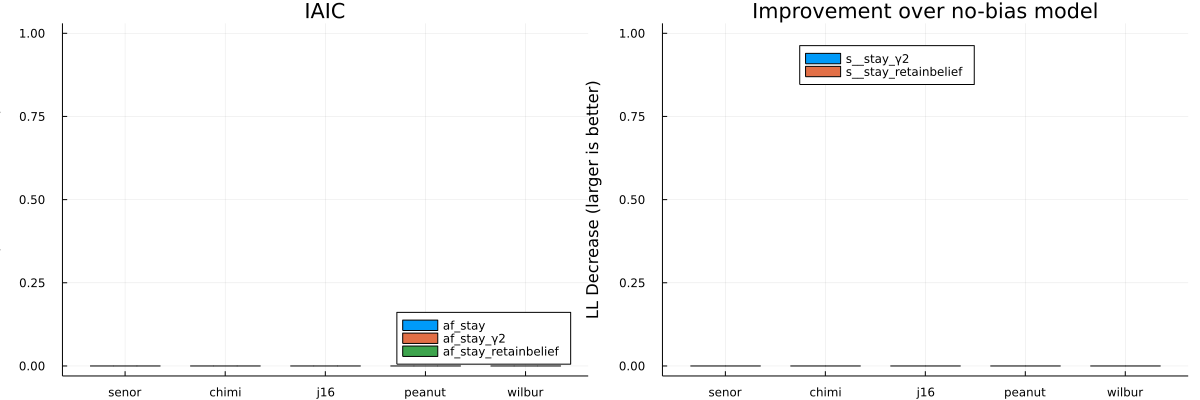

In [4]:
fns = vcat(fns_q[4:6])
(results, aics) = load_q_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    # labels=["leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    labels = permutedims([x[1][5:end] for x in fns]),
    # permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames)
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][7:end] for x in fns[2:end]]),
    legend=(0.35,0.9),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over no-bias model",
)
plot(p1, p2, size=(1200, 400))

Missing: ../results/q_biases/q_leaf_stay_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_stay_γ2_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_stay_retainbelief_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_initialQ_stay_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_initialQ_stay_γ2_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_initialQ_stay_retainbelief_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_stay_rewscaled_chimi.jld2
Missing: ../results/q_biases/q_leaf_stay_γ2_rewscaled_chimi.jld2
Missing: ../results/q_biases/q_leaf_stay_retainbelief_rewscaled_chimi.jld2
Missing: ../results/q_biases/q_leaf_initialQ_stay_rewscaled_chimi.jld2
Missing: ../results/q_biases/q_leaf_initialQ_stay_γ2_rewscaled_chimi.jld2
Missing: ../results/q_biases/q_leaf_initialQ_stay_retainbelief_rewscaled_chimi.jld2
Missing: ../results/q_biases/q_leaf_stay_rewscaled_j16.jld2
Missing: ../results/q_biases/q_leaf_stay_γ2_rewscaled_j16.jld2
Missing: ../res

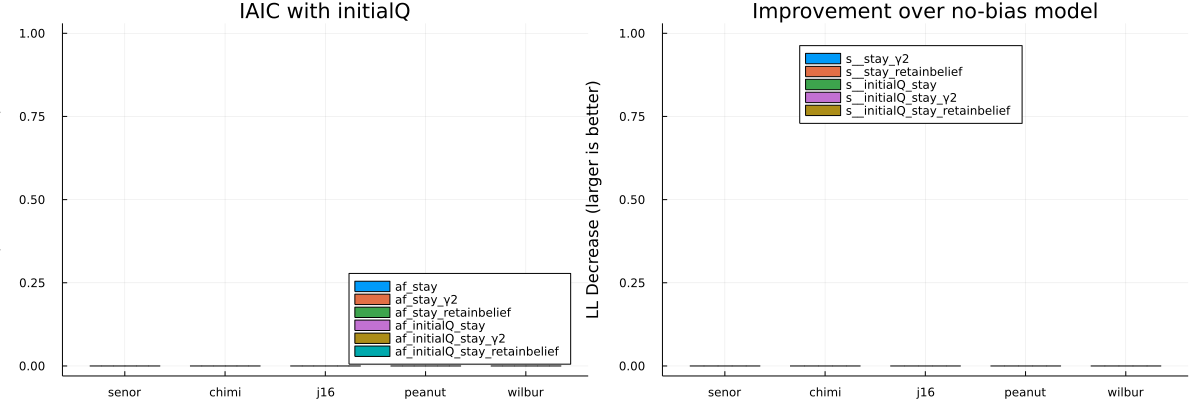

In [5]:
fns = vcat(fns_q[4:6], fns_q_initialQ[4:6])
(results, aics) = load_q_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    # labels=["leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    labels = permutedims([x[1][5:end] for x in fns]),
    # permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames)
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC with initialQ",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims(["s_"*x[1][7:end] for x in fns[2:end]]),
    legend=(0.35,0.9),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over no-bias model",
)
plot(p1, p2, size=(1200, 400))

# Stem and Leaf Biases

In [6]:
fns = vcat(fns_q[4], fns_q_stay[[5,6]], fns_q_initialQ_stay[[5,6]], fns_q_initialQ_stay_γ2[[5,6]])
(results, aics) = load_q_results(animals, fns)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    # labels=["leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    labels = permutedims([x[1][1:end] for x in fns]),
    # permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames)
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][1:end] for x in fns[2:end]]),
    legend=(0.35,0.9),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over stay model",
    ylim=(-70,800),
)
plot(p1, p2, size=(1200, 400))

Missing: ../results/q_biases/q_leaf_stay_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_stay_turn_leafspatial_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_stay_turn_leafturn_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_initialQ_stay_turn_leafspatial_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_initialQ_stay_turn_leafturn_rewscaled_senor.jld2


Error encountered while load File{DataFormat{:JLD2}, String}("../results/q_biases/q_leaf_initialQ_stay_turn_leafspatial_γ2_rewscaled_senor.jld2").

Fatal error:


LoadError: KeyError: key "q_leaf_initialQ_stay_turn_leafspatial_γ2_rewscaled_senor" not found
Stacktrace:
  [1] [0m[1mgetindex[22m[0m[1m([22m[90mg[39m::[0mJLD2.Group[90m{JLD2.JLDFile{JLD2.MmapIO}}[39m, [90mname[39m::[0mString[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mgroups.jl:101[24m[39m
  [2] [0m[1mread[22m
[90m    @ [39m[90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mJLD2.jl:389[24m[39m[90m [inlined][39m
  [3] [0m[1m(::JLD2.var"#75#76"{String})[22m[0m[1m([22m[90mfile[39m::[0mJLD2.JLDFile[90m{JLD2.MmapIO}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mfileio.jl:46[24m[39m
  [4] [0m[1mjldopen[22m[0m[1m([22m::[0mFunction, ::[0mString, ::[0mVararg[90m{String}[39m; [90mkws[39m::[0mBase.Pairs[90m{Symbol, Union{}, Tuple{}, NamedTuple{(), Tuple{}}}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9

# Comparison with HMM

In [7]:
fns_hmm_stay = [
    ("hmm_leaf_stay_γ2", run_hmm_leaf_stay_γ2),
    ("hmm_leaf_stay_retainbelief", run_hmm_leaf_stay_retainbelief),
    ("hmm_leaf_stay_turn", run_hmm_leaf_stay_turn),
    ("hmm_leaf_stay_spatial", run_hmm_leaf_stay_spatial),
    ("hmm_leaf_stay_leafturn", run_hmm_leaf_stay_leafturn),
    ("hmm_leaf_stay_leafspatial", run_hmm_leaf_stay_leafspatial),
    ("hmm_leaf_stay_turn_leafturn", run_hmm_leaf_stay_turn_leafturn),
    ("hmm_leaf_stay_turn_leafspatial", run_hmm_leaf_stay_turn_leafspatial),
    ("hmm_leaf_stay_spatial_leafturn", run_hmm_leaf_stay_spatial_leafturn),
    ("hmm_leaf_stay_spatial_leafspatial", run_hmm_leaf_stay_spatial_leafspatial),    
    ]

10-element Vector{Tuple{String, Function}}:
 ("hmm_leaf_stay_γ2", run_hmm_leaf_stay_γ2)
 ("hmm_leaf_stay_retainbelief", run_hmm_leaf_stay_retainbelief)
 ("hmm_leaf_stay_turn", run_hmm_leaf_stay_turn)
 ("hmm_leaf_stay_spatial", run_hmm_leaf_stay_spatial)
 ("hmm_leaf_stay_leafturn", run_hmm_leaf_stay_leafturn)
 ("hmm_leaf_stay_leafspatial", run_hmm_leaf_stay_leafspatial)
 ("hmm_leaf_stay_turn_leafturn", run_hmm_leaf_stay_turn_leafturn)
 ("hmm_leaf_stay_turn_leafspatial", run_hmm_leaf_stay_turn_leafspatial)
 ("hmm_leaf_stay_spatial_leafturn", run_hmm_leaf_stay_spatial_leafturn)
 ("hmm_leaf_stay_spatial_leafspatial", run_hmm_leaf_stay_spatial_leafspatial)

In [8]:
function load_hmm_results(animals, fns; rewscaled=true)
    results = Dict()
    aics = zeros(length(animals), length(fns))
    if rewscaled
        add_rewscaled = "_rewscaled"
    else
        add_rewscaled = ""
    end
    for (i, animal) in enumerate(animals)
        for (j, (fname, fn)) in enumerate(fns)
            filename = "$(filepath)/results/hmm_biases/$(fname)$(add_rewscaled)_$(animal).jld2"
            if (isfile(filename))
                results[(animal, fname)] = load(filename, "$(fname)$(add_rewscaled)_$(animal)")
                aics[i, j] = iaic(results[(animal, fname)])
            else
                println("Missing: $(filename)")
            end
        end
    end
    (results, aics)
end

load_hmm_results (generic function with 1 method)

In [9]:
fns1 = vcat(fns_q[4], fns_q_stay[[5,6]], fns_q_stay_γ2[[5,6]], fns_q_initialQ_stay[[5,6]], fns_q_initialQ_stay_γ2[[5,6]])
(results1, aics1) = load_q_results(animals, fns1)
fns2 = vcat(fns_hmm_stay[[5,6]])
(results2, aics2) = load_hmm_results(animals, fns2)
results = merge(results1, results2)
aics = hcat(aics1, aics2)
fns = vcat(fns1, fns2)
p1 = groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    # labels=["leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    labels = permutedims([x[1][1:end] for x in fns]),
    # permutedims(results[("peanut", "hmm_leaf_stay_turn")].varnames)
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)
p2 = groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels = permutedims([x[1][1:end] for x in fns[2:end]]),
    legend=(0.35,0.9),
    ylabel="LL Decrease (larger is better)",
    title="Improvement over stay model",
    ylim=(-200,1100),
)
plot(p1, p2, size=(1200, 400))

Missing: ../results/q_biases/q_leaf_stay_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_stay_turn_leafspatial_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_stay_turn_leafturn_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_stay_turn_leafspatial_γ2_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_stay_turn_leafturn_γ2_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_initialQ_stay_turn_leafspatial_rewscaled_senor.jld2
Missing: ../results/q_biases/q_leaf_initialQ_stay_turn_leafturn_rewscaled_senor.jld2


Error encountered while load File{DataFormat{:JLD2}, String}("../results/q_biases/q_leaf_initialQ_stay_turn_leafspatial_γ2_rewscaled_senor.jld2").

Fatal error:


LoadError: KeyError: key "q_leaf_initialQ_stay_turn_leafspatial_γ2_rewscaled_senor" not found
Stacktrace:
  [1] [0m[1mgetindex[22m[0m[1m([22m[90mg[39m::[0mJLD2.Group[90m{JLD2.JLDFile{JLD2.MmapIO}}[39m, [90mname[39m::[0mString[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mgroups.jl:101[24m[39m
  [2] [0m[1mread[22m
[90m    @ [39m[90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mJLD2.jl:389[24m[39m[90m [inlined][39m
  [3] [0m[1m(::JLD2.var"#75#76"{String})[22m[0m[1m([22m[90mfile[39m::[0mJLD2.JLDFile[90m{JLD2.MmapIO}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9Gt0/src/[39m[90m[4mfileio.jl:46[24m[39m
  [4] [0m[1mjldopen[22m[0m[1m([22m::[0mFunction, ::[0mString, ::[0mVararg[90m{String}[39m; [90mkws[39m::[0mBase.Pairs[90m{Symbol, Union{}, Tuple{}, NamedTuple{(), Tuple{}}}[39m[0m[1m)[22m
[90m    @ [39m[35mJLD2[39m [90m~/.julia/packages/JLD2/k9